In [1]:
from pymongo import MongoClient
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
client = MongoClient("mongodb://localhost:27017/")

db = client["sample_supplies"]

collection = db["sales"]

print(f"total sales:{ collection.count_documents({}):,}")

total sales:5,000


# Q8: What is the average customer satisfaction rating of all customers in the dataset?

In [8]:
#code for Query 8
from pprint import pprint

pipeline = [
    {
        "$group": {
            "_id": None,
            "AverageCustomerSatisfaction": {"$avg": "$customer.satisfaction"}
        }
    }
]

avg = list(collection.aggregate(pipeline))
pprint(avg)

print(f"Average Customer Satisfaction Rating: {avg[0]['AverageCustomerSatisfaction']:.2f}")


avg_df = pd.DataFrame({
    "Metric": ["Average Customer Satisfaction"],
    "Rating": [avg[0]["AverageCustomerSatisfaction"]]
})

avg_df

[{'AverageCustomerSatisfaction': 3.7932, '_id': None}]
Average Customer Satisfaction Rating: 3.79


,Metric,Rating
0,Average Customer Satisfaction,3.7932


## Code for Visualization

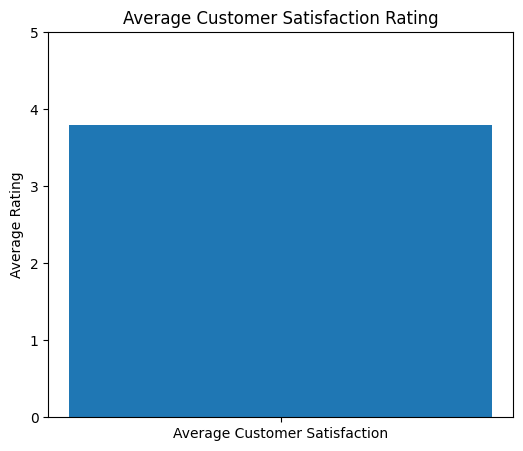

In [10]:
plt.figure(figsize=(6,5))

plt.bar(avg_df["Metric"], avg_df["Rating"])

plt.title("Average Customer Satisfaction Rating")
plt.ylabel("Average Rating")

plt.ylim(0,5)

plt.show()